In [14]:
!pip install sentence-transformers

In [15]:
sentences = [
    # Cricket (3)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",

    # Cooking (3)
    "Add salt and spices to enhance the flavor",
    "Boil the pasta until it is soft",
    "Cooking requires patience and skill",

    # Cybersecurity (4)
    "Use strong passwords to protect your data",
    "Encryption ensures secure communication",
    "Firewalls help prevent unauthorized access",
    "Phishing attacks can steal sensitive information"
]



In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix.shape)

(10, 10)


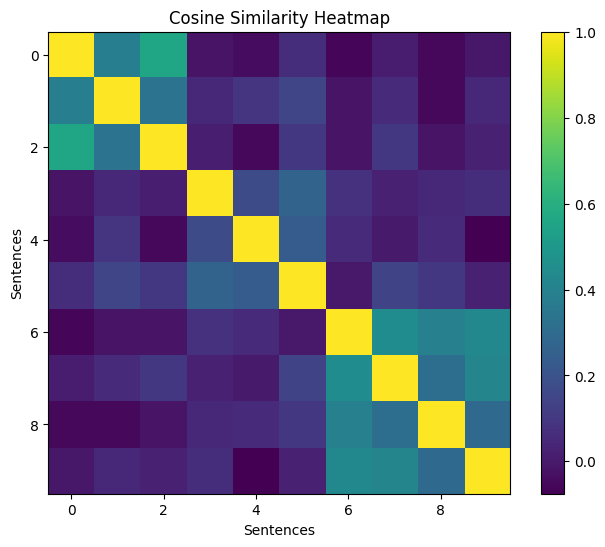

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(similarity_matrix)
plt.colorbar()
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.show()

In [13]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

print("Top 2 similar sentences:\n")

for i in top_indices:
    print(sentences[i])
    print("Score:", similarities[i])
    print()

Top 2 similar sentences:

The batsman scored a century in the match
Score: 0.56821966

The bowler delivered a fast yorker
Score: 0.5413827

